In [1]:
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("napistu_torch")

In [2]:
import os
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from napistu_torch.evaluation.evaluation_manager import EvaluationManager
from napistu_torch.evaluation.model_comparison import compare_embeddings
from napistu_torch.evaluation.pathways import calculate_pathway_similarities
from napistu_torch.lightning.workflows import predict
from napistu_torch.utils.torch_utils import select_device
from napistu_torch.visualization.basic_metrics import plot_model_comparison
from napistu_torch.visualization.embeddings import layout_umap, plot_coordinates_with_masks


/Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/scraps/pytorch/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# EXPERIMENT_DIR = Path("edge_prediction/sage_baseline")
#evaluation_manager = EvaluationManager(EXPERIMENT_DIR)
#experiment_dict = resume_experiment(evaluation_manager)
#test_results = test(experiment_dict, evaluation_manager.best_checkpoint_path)

## Adapting Napistu to Graph neural networks

1. Adding relevant vertex and edge attributes
    a. creating appropriate transformations for encodings
2. `NapistuData` - *PyG* `Data` with Napistu-specific attributes and methods
3. `NapistuDataStore` - Caching and easily retrieving `NapistuData` objects which can be used by multiple models
4. Leaning on the torch ecosystem for model specification and training
5. Self-supervised edge prediction
    a. negative sampling with hard negatives

In [4]:
# setting up the experiment
from napistu_torch.load.gcs import gcs_model_to_store
from napistu_torch.configs import ExperimentConfig, ModelConfig, DataConfig, TaskConfig, TrainingConfig
from napistu_torch.models.constants import ENCODERS, HEADS

In [5]:
OVERWRITE = False

EXPERIMENTS_DIR = Path("edge_prediction")

EXPERIMENTS = [
    # leave this as a list so it defines plot order
    "20251106_gcn_baseline",
    "20251106_gcn_edge_encoding",
    "20251106_sage_baseline",
    "20251106_graphconv_baseline",
    "20251106_graphconv_edge_encoding"
]

EXPERIMENT_LABELS = {
    "20251106_gcn_baseline" : "GCN",
    "20251106_gcn_edge_encoding" : "GCN + Edge Encoding",
    "20251106_sage_baseline" : "SAGE",
    "20251106_graphconv_baseline" : "GraphConv",
    "20251106_graphconv_edge_encoding" : "GraphConv + Edge Encoding"
}

ordered_labels = [EXPERIMENT_LABELS[exp] for exp in EXPERIMENTS]

OUT_DIR = Path("edge_prediction")
TOP_MODEL_NAME = "GraphConv + Edge Encoding"
EMBEDDING_COMPARISONS_PATH = OUT_DIR / "embedding_comparisons.tsv"

In [6]:
eval_managers = {
    EXPERIMENT_LABELS[out_dir]: EvaluationManager(EXPERIMENTS_DIR / out_dir) for out_dir in EXPERIMENTS
}

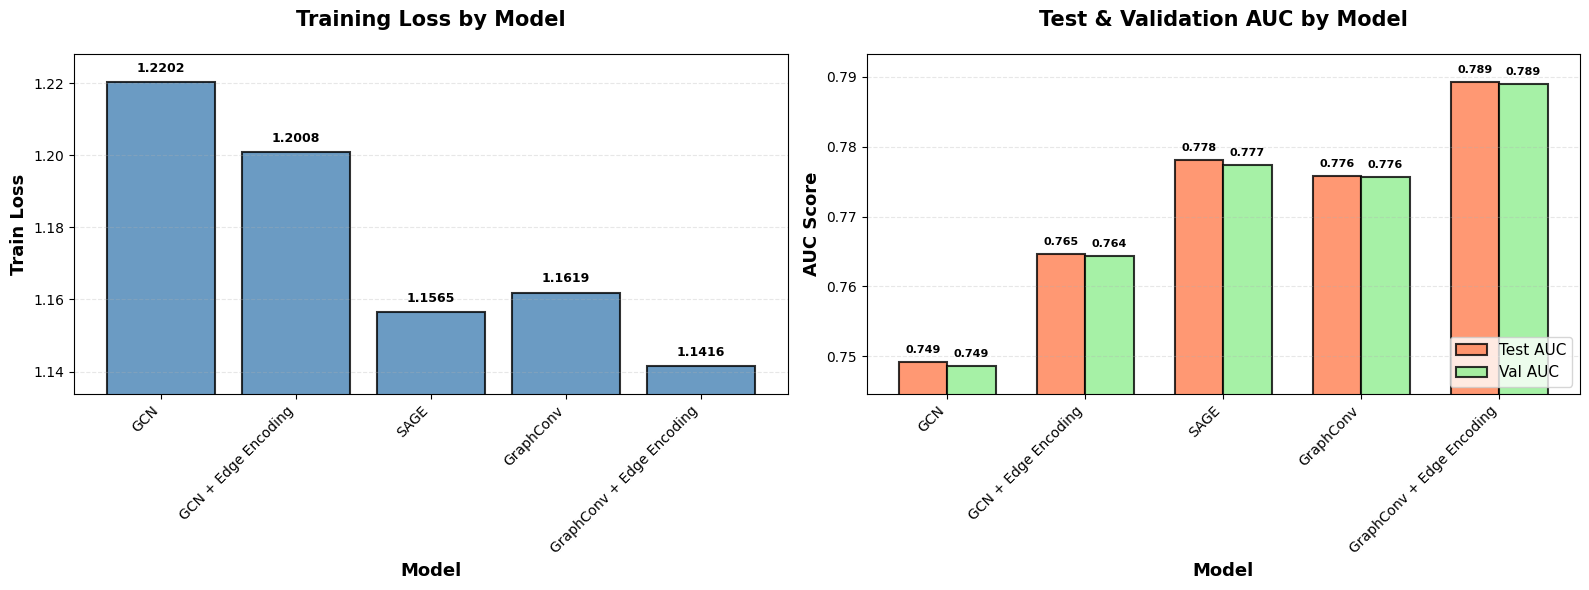

In [7]:
# Extract models summaries directly from W&B using their API
run_summaries = {exp: manager.get_run_summary() for exp, manager in eval_managers.items()}

# visualize model comparison
fig, (ax1, ax2) = plot_model_comparison(run_summaries, ordered_labels)
plt.show()

In [8]:
top_model_manager = eval_managers[TOP_MODEL_NAME]
napistu_data = top_model_manager.load_napistu_data()
napistu_data_store = top_model_manager.get_store()
napistu_graph = napistu_data_store.load_napistu_graph()

# pull out the node types and create a mask to distinguish species and reactions
node_types = napistu_graph.get_vertex_series("node_type")
is_species_mask = (node_types == "species").values

node_types.value_counts()


INFO:napistu_torch.napistu_data_store:Loading NapistuData from /Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/scraps/pytorch/.store/napistu_data/edge_prediction.pt


node_type
reaction    402805
species      43814
Name: count, dtype: int64

In [9]:
## Extract model embeddings
edge_encodings = {}
species_embeddings = {}
for exp, evaluation_manager in eval_managers.items():
    # load the model and data
    model = evaluation_manager.load_model_from_checkpoint()
    napistu_data = evaluation_manager.load_napistu_data()
    
    # pull out learned edge weights (if an edge encoder is present)
    if model.task.encoder.edge_weighting_type == "learned_encoder":
        edge_encodings[exp] = model.get_learned_edge_weights(napistu_data)
    
    # pull out the vertex embeddings
    embeddings = model.get_embeddings(napistu_data)
    species_embeddings[exp] = embeddings[is_species_mask]

    # cleanup
    evaluation_manager.experiment_dict = None

INFO:napistu_torch.ml.wandb:Resuming W&B run: hzeu5a8n
wandb: Currently logged in as: shackett (napistu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


INFO:napistu_torch.ml.wandb:Successfully resumed W&B run: https://wandb.ai/napistu/napistu-experiments/runs/hzeu5a8n
INFO:napistu_torch.lightning.workflows:Creating EdgeBatchDataModule with batches_per_epoch = 20...
INFO:napistu_torch.lightning.datamodule:Creating/loading store from config
INFO:napistu_torch.napistu_data_store:Loading existing store from /Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/scraps/pytorch/.store
INFO:napistu_torch.napistu_data_store:Ensuring required artifacts exist: ['edge_strata_by_node_species_type', 'comprehensive_pathway_memberships', 'edge_strata_by_node_type', 'edge_prediction']
INFO:napistu_torch.napistu_data_store:All requested artifacts already exist in store
INFO:napistu_torch.napistu_data_store:All requested artifacts already exist in store
INFO:napistu_torch.lightning.datamodule:Loading napistu_data 'edge_prediction' from store
INFO:napistu_torch.napistu_data_store:Loading NapistuData from /Users/sean/Desktop/GITHUB/napistu/lib/napistu-

## Comparing vertex embeddings

In [10]:
OVERWRITE = False
if os.path.isfile(EMBEDDING_COMPARISONS_PATH) and not OVERWRITE:
    embedding_comparisons = pd.read_csv(EMBEDDING_COMPARISONS_PATH, sep="\t", index_col=0)
else:
    device = select_device(mps_valid = True)
    embedding_comparisons = compare_embeddings(species_embeddings, device)
    embedding_comparisons.to_csv(EMBEDDING_COMPARISONS_PATH, sep="\t", index_col=False)


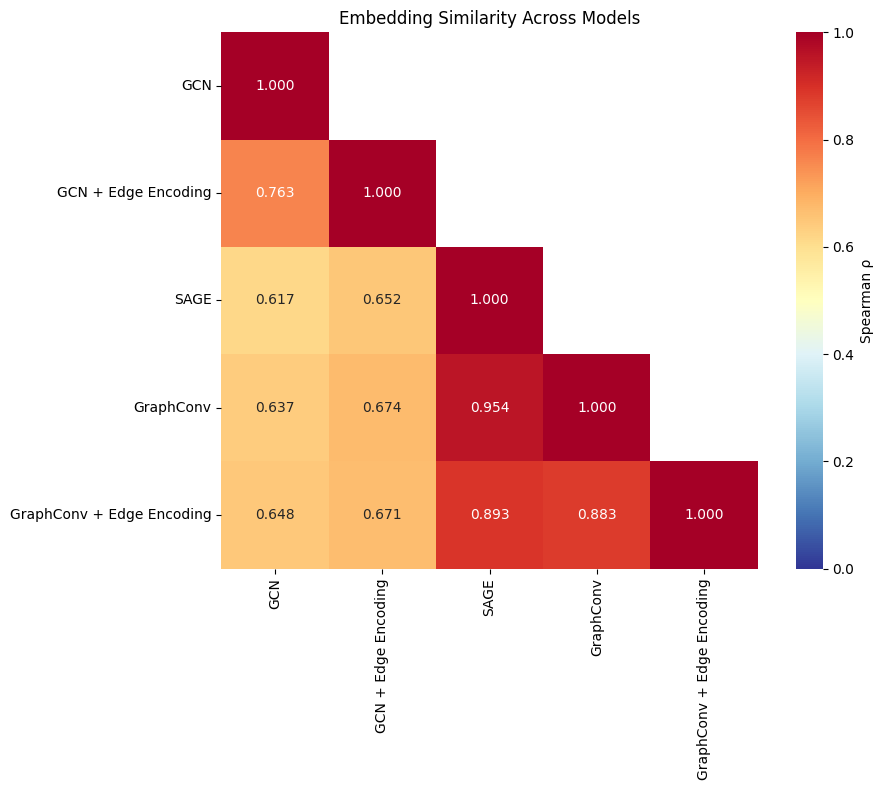

In [11]:
def create_correlation_heatmap(embedding_comparisons: pd.DataFrame, 
                               model_order: list[str] | None = None) -> pd.DataFrame:
    """
    Convert pairwise comparison results into a symmetric correlation matrix.
    
    Parameters
    ----------
    embedding_comparisons : pd.DataFrame
        DataFrame with columns: model1, model2, spearman_rho
    model_order : list[str] | None
        Optional list specifying the order of models in the matrix.
        If None, models are sorted alphabetically.
        
    Returns
    -------
    corr_matrix : pd.DataFrame
        Symmetric correlation matrix with models as both index and columns
    """
    # Get all unique models
    all_models = set(embedding_comparisons['model1'].unique()) | \
                 set(embedding_comparisons['model2'].unique())
    
    # Use provided order or default to sorted
    if model_order is None:
        models = sorted(all_models)
    else:
        # Validate that all models in data are in the provided order
        missing_models = all_models - set(model_order)
        if missing_models:
            raise ValueError(f"Models in data but not in model_order: {missing_models}")
        # Use only models that exist in the data, in the specified order
        models = [m for m in model_order if m in all_models]
    
    # Initialize matrix with 1s on diagonal
    corr_matrix = pd.DataFrame(np.eye(len(models)), 
                               index=models, 
                               columns=models)
    
    # Fill in the correlations (both upper and lower triangles)
    for _, row in embedding_comparisons.iterrows():
        corr_matrix.loc[row['model1'], row['model2']] = row['spearman_rho']
        corr_matrix.loc[row['model2'], row['model1']] = row['spearman_rho']
    
    return corr_matrix

corr_matrix = create_correlation_heatmap(embedding_comparisons, model_order=ordered_labels)

# Display as heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r', 
            mask=mask, vmin=0, vmax=1, square=True, 
            cbar_kws={'label': 'Spearman ρ'})
plt.title('Embedding Similarity Across Models')
plt.tight_layout()
plt.show()

## Comparing learned edge weights

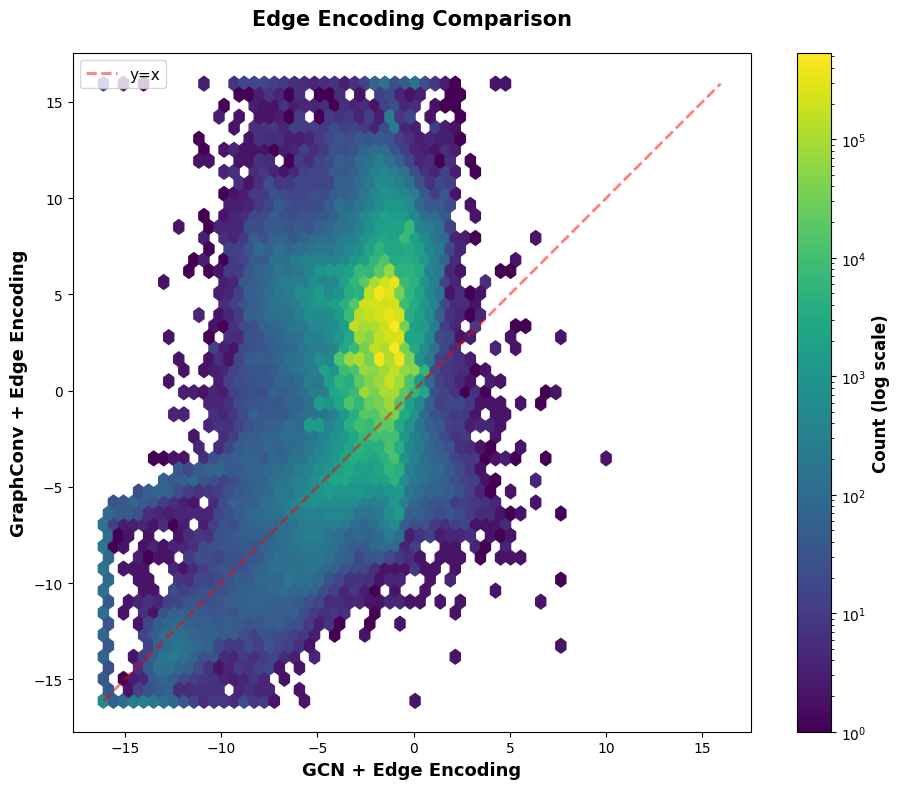

In [12]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from matplotlib.colors import LogNorm


def safe_logit(p: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    """
    Numerically stable logit transformation.
    
    Maps [0, 1] → (-∞, +∞) via log(p / (1 - p))
    
    Parameters
    ----------
    p : torch.Tensor
        Probabilities in range [0, 1]
    eps : float
        Small constant to avoid log(0) and division by zero
        
    Returns
    -------
    torch.Tensor
        Logit-transformed values on real number line
    """
    p = torch.clamp(p, eps, 1 - eps)
    return torch.log(p / (1 - p))


def plot_edge_encoding_hexbin(
    tensor1: torch.Tensor,
    tensor2: torch.Tensor,
    label1: str = "Model 1",
    label2: str = "Model 2",
    transform_to_logit: bool = True,
    gridsize: int = 50,
    cmap: str = 'viridis',
    figsize: tuple = (10, 8),
) -> tuple:
    """
    Create hexbin plot comparing two edge encoding tensors.
    
    Parameters
    ----------
    tensor1, tensor2 : torch.Tensor
        Edge encoding tensors to compare. Should be in [0, 1] if transform_to_logit=True.
    label1, label2 : str
        Labels for x and y axes
    transform_to_logit : bool
        If True, apply logit transformation to convert [0, 1] → (-∞, +∞)
    gridsize : int
        Number of hexagons in x-direction
    cmap : str
        Matplotlib colormap name
    figsize : tuple
        Figure size as (width, height)
        
    Returns
    -------
    fig : matplotlib.figure.Figure
    ax : matplotlib.axes.Axes
    """
    # Apply logit transformation if requested
    if transform_to_logit:
        tensor1 = safe_logit(tensor1)
        tensor2 = safe_logit(tensor2)
    
    # Convert to numpy
    if torch.is_tensor(tensor1):
        x = tensor1.cpu().numpy()
    else:
        x = np.array(tensor1)
    
    if torch.is_tensor(tensor2):
        y = tensor2.cpu().numpy()
    else:
        y = np.array(tensor2)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create hexbin plot with log-scaled color
    hexbin = ax.hexbin(
        x, y,
        gridsize=gridsize,
        cmap=cmap,
        mincnt=1,
        norm=LogNorm()
    )
    
    # Add colorbar
    cb = plt.colorbar(hexbin, ax=ax)
    cb.set_label('Count (log scale)', fontsize=12, fontweight='bold')
    
    # Labels and title
    ax.set_xlabel(label1, fontsize=13, fontweight='bold')
    ax.set_ylabel(label2, fontsize=13, fontweight='bold')
    ax.set_title('Edge Encoding Comparison', fontsize=15, fontweight='bold', pad=20)
    
    # Add diagonal reference line (y=x)
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax.plot([min_val, max_val], [min_val, max_val], 
            'r--', alpha=0.5, linewidth=2, label='y=x')
    ax.legend(loc='upper left', fontsize=11)
    
    # Equal aspect ratio
    ax.set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    
    return fig, ax


# Usage
tensor1 = edge_encodings["GCN + Edge Encoding"]
tensor2 = edge_encodings["GraphConv + Edge Encoding"]

fig, ax = plot_edge_encoding_hexbin(
    tensor1,
    tensor2,
    label1="GCN + Edge Encoding",
    label2="GraphConv + Edge Encoding",
    transform_to_logit=True,
    gridsize=50,
    cmap='viridis'
)

plt.show()

## Evaluating the GraphConv w/ edge encoding

### Molecular similarity
- UMAP
- pathway analysis


In [13]:
# load comprehensive pathway assignments for validation
comprehensive_pathway_assignments = napistu_data_store.load_vertex_tensor("comprehensive_pathway_memberships")
pathway_assignments = comprehensive_pathway_assignments.align_to_napistu_data(napistu_data, inplace=False).data

embeddings = species_embeddings[TOP_MODEL_NAME]

INFO:napistu_torch.napistu_data_store:Loading VertexTensor from /Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/scraps/pytorch/.store/vertex_tensors/comprehensive_pathway_memberships.pt


In [14]:
pathway_similarities = calculate_pathway_similarities(
    embedding_matrix = embeddings,
    pathway_assignments = pathway_assignments[is_species_mask],
    pathway_names = comprehensive_pathway_assignments.feature_names,
)

/Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/scraps/pytorch/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


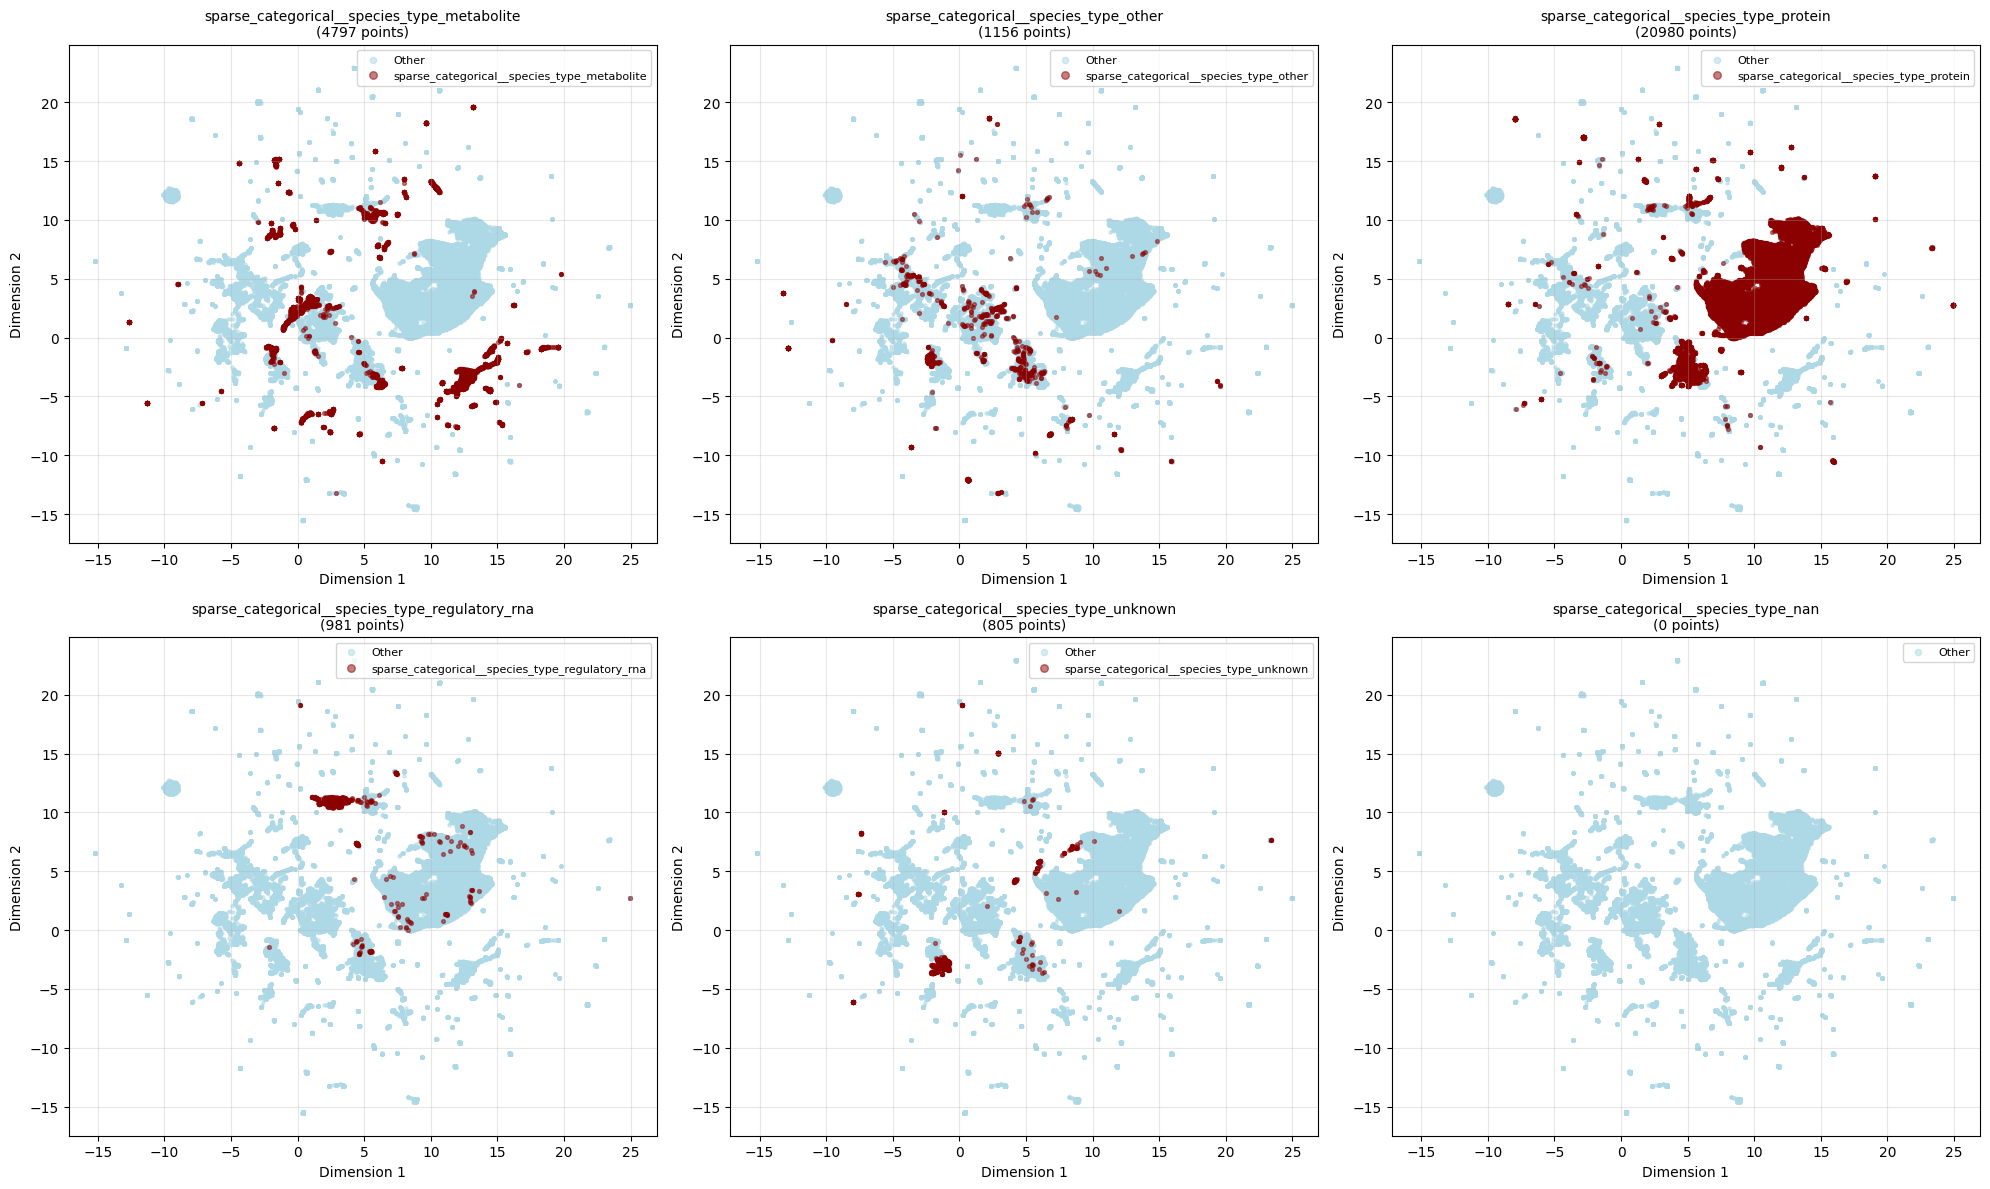

In [22]:
umap_layout_species = layout_umap(embeddings)

mask = [bool(re.search("__species_type", x)) for x in napistu_data.get_vertex_feature_names()]
indices = [i for i, m in enumerate(mask) if m]
masks = napistu_data.x[:, indices]

# only look at the vertices with embedding values
masks = masks[is_species_mask]
mask_names = [x for x, m in zip(napistu_data.get_vertex_feature_names(), mask) if m]

fig, axes = plot_coordinates_with_masks(
    coordinates=umap_layout_species,
    masks=masks,  # Your tensor of masks
    mask_names=mask_names,
    figsize=(20, 12),
    ncols=3,
    cmap_bg='lightblue',
    cmap_fg='darkred',
    alpha=0.5,
    s=5
)

plt.show()

### Learned edge weights
- comparing edge weights to individual edge attributes (saliency analysis)

In [16]:
from typing import Union

def compute_edge_attribute_correlations(
    edge_attr: torch.Tensor, 
    edge_predictions: Union[list[torch.Tensor], torch.Tensor],
    edge_feature_names: list[str],
) -> pd.DataFrame:
    """
    Compute Pearson correlation between edge attributes and predictions for each attribute.
    Vectorized implementation - no loops!
    
    Parameters
    ----------
    edge_attr : torch.Tensor
        Shape [num_edges, num_attributes] - the true edge attributes
    edge_predictions : list[torch.Tensor]
        List of length num_attributes, each tensor has shape [num_edges]
        
    Returns
    -------
    correlations : pd.DataFrame
        DataFrame with columns: attribute_idx, pearson_r
    """
    # Stack the list of predictions into a tensor [num_attributes, num_edges]
    # Then transpose to [num_edges, num_attributes]
    if isinstance(edge_predictions, list):
        pred_stacked = torch.stack(edge_predictions, dim=1)  # Stack along attribute dimension
    else:
        if edge_predictions.dim() == 1:
            edge_predictions = edge_predictions.unsqueeze(1)
        pred_stacked = edge_predictions
    
    # Center both tensors (subtract mean along edge dimension, dim=0)
    true_centered = edge_attr - edge_attr.mean(dim=0, keepdim=True)
    pred_centered = pred_stacked - pred_stacked.mean(dim=0, keepdim=True)
    
    # Compute correlation for all attributes at once
    numerator = (true_centered * pred_centered).sum(dim=0)
    true_std = torch.sqrt((true_centered ** 2).sum(dim=0))
    pred_std = torch.sqrt((pred_centered ** 2).sum(dim=0))
    
    pearson_r = numerator / (true_std * pred_std)
    
    # Create DataFrame
    correlations_df = pd.DataFrame({
        'attribute_idx': range(len(pearson_r)),
        'feature_name': edge_feature_names,
        'pearson_r': pearson_r.cpu().numpy()
    })
    correlations_df["absolute_pearson_r"] = correlations_df["pearson_r"].abs()
    
    return correlations_df


In [17]:

correlations_df = compute_edge_attribute_correlations(napistu_data.edge_attr, edge_encodings[TOP_MODEL_NAME], napistu_data.get_edge_feature_names())
correlations_df.sort_values(["absolute_pearson_r"], ascending=False).head(10)

,attribute_idx,feature_name,pearson_r,absolute_pearson_r
57,57,sparse_numeric__value_STRING_coexpression_tran...,-0.503631,0.503631
65,65,sparse_numeric__value_STRING_neighborhood_tran...,-0.461831,0.461831
61,61,sparse_numeric__value_STRING_experiments,-0.454908,0.454908
17,17,numeric,0.353195,0.353195
62,62,sparse_numeric__value_STRING_experiments_trans...,-0.295271,0.295271
58,58,sparse_numeric__value_STRING_combined_score,-0.292090,0.292090
68,68,sparse_numeric__value_string_wt,0.269362,0.269362
6,6,categorical__sbo_term_SBO:0000336,0.262707,0.262707
19,19,binary__r_isreversible,0.249313,0.249313
55,55,sparse_numeric__is,0.219006,0.219006


### Edge predictions (calibration across strata)

In [18]:
edge_predictions = predict(
    top_model_manager.get_experiment_dict(),
    checkpoint=top_model_manager.best_checkpoint_path
)

correlations_df = compute_edge_attribute_correlations(napistu_data.edge_attr, edge_predictions, napistu_data.get_edge_feature_names())
correlations_df.sort_values(["absolute_pearson_r"], ascending=False).head(10)

INFO:napistu_torch.ml.wandb:Resuming W&B run: rc0lzckh
/Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/scraps/pytorch/.venv/lib/python3.11/site-packages/lightning/pytorch/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
INFO:napistu_torch.ml.wandb:Successfully resumed W&B run: https://wandb.ai/napistu/napistu-experiments/runs/hzeu5a8n
INFO:napistu_torch.lightning.workflows:Creating EdgeBatchDataModule with batches_per_epoch = 20...
INFO:napistu_torch.lightning.datamodule:Creating/loading store from config
INFO:napistu_torch.napistu_data_store:Loading existing store from /Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/scraps/pytorch/.store
INFO:napistu_torch.napistu_data_store:Ensuring required artifacts exist: ['edge_strata_by_node_species_type', 'comprehensive_pathway_memberships', 'edge_strata_by_node_type'

Predicting DataLoader 0: 100%|██████████| 1/1 [00:07<00:00,  0.13it/s]


,attribute_idx,feature_name,pearson_r,absolute_pearson_r
6,6,categorical__sbo_term_SBO:0000336,-0.233159,0.233159
19,19,binary__r_isreversible,-0.232956,0.232956
56,56,sparse_numeric__value_STRING_coexpression,0.222576,0.222576
7,7,categorical__sbo_term_SBO:0000459,0.177158,0.177158
53,53,sparse_numeric__is_Reactome-FI_fi_score,0.157302,0.157302
17,17,numeric,-0.157089,0.157089
22,22,sparse_categorical__OmniPath_consensus_directi...,0.153027,0.153027
58,58,sparse_numeric__value_STRING_combined_score,0.148071,0.148071
57,57,sparse_numeric__value_STRING_coexpression_tran...,0.144436,0.144436
68,68,sparse_numeric__value_string_wt,-0.142422,0.142422


In [19]:
napistu_data = napistu_data_store.load_napistu_data("edge_prediction")
edge_strata = napistu_data_store.load_pandas_df("edge_strata_by_node_type")
extended_edge_strata = napistu_data_store.load_pandas_df("edge_strata_by_node_species_type")

INFO:napistu_torch.napistu_data_store:Loading NapistuData from /Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/scraps/pytorch/.store/napistu_data/edge_prediction.pt
INFO:napistu_torch.napistu_data_store:Loading pandas DataFrame from /Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/scraps/pytorch/.store/pandas_dfs/edge_strata_by_node_type.parquet
INFO:napistu_torch.napistu_data_store:Loading pandas DataFrame from /Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/scraps/pytorch/.store/pandas_dfs/edge_strata_by_node_species_type.parquet


In [20]:
import pandas as pd
from typing import List
import torch

def edge_prediction_strata_analysis(edge_predictions: List[torch.Tensor], edge_strata: pd.DataFrame):

    n_predictions = len(edge_predictions[0])
    n_strata = len(edge_strata)
    if "edge_strata" not in edge_strata.columns:
        raise ValueError("edge_strata column not found in edge_strata DataFrame")

    if n_predictions != n_strata:
        raise ValueError(f"Number of predictions ({n_predictions}) does not match number of strata ({n_strata})")

    tensor_np = edge_predictions[0].cpu().numpy()

    # Create a DataFrame or Series with the tensor values and strata index
    df = pd.DataFrame({
        'value': tensor_np,
        'edge_strata': edge_strata["edge_strata"]  # or just edge_strata if already aligned
    })

    # Group by strata and calculate mean
    strata_means = (
        df.groupby('edge_strata')['value'].mean()
        .rename("average_prediction_probability")
    ).to_frame()

    strata_frequency = edge_strata.value_counts("edge_strata").to_frame()

    return strata_means.join(strata_frequency).sort_values("average_prediction_probability", ascending=False)

In [21]:
edge_prediction_strata_analysis(edge_predictions, extended_edge_strata)

,average_prediction_probability,count
edge_strata,,
species (regulatory_rna) -> species (regulatory_rna),1.000000,22
reaction -> species (drug),0.999970,2451
species (drug) -> reaction,0.999880,2856
species (unknown) -> reaction,0.996721,15028
species (metabolite) -> species (metabolite),0.996076,10
species (metabolite) -> reaction,0.995753,12210
species (other) -> species (metabolite),0.994501,85
reaction -> species (metabolite),0.994113,12747
species (metabolite) -> species (other),0.988052,13
